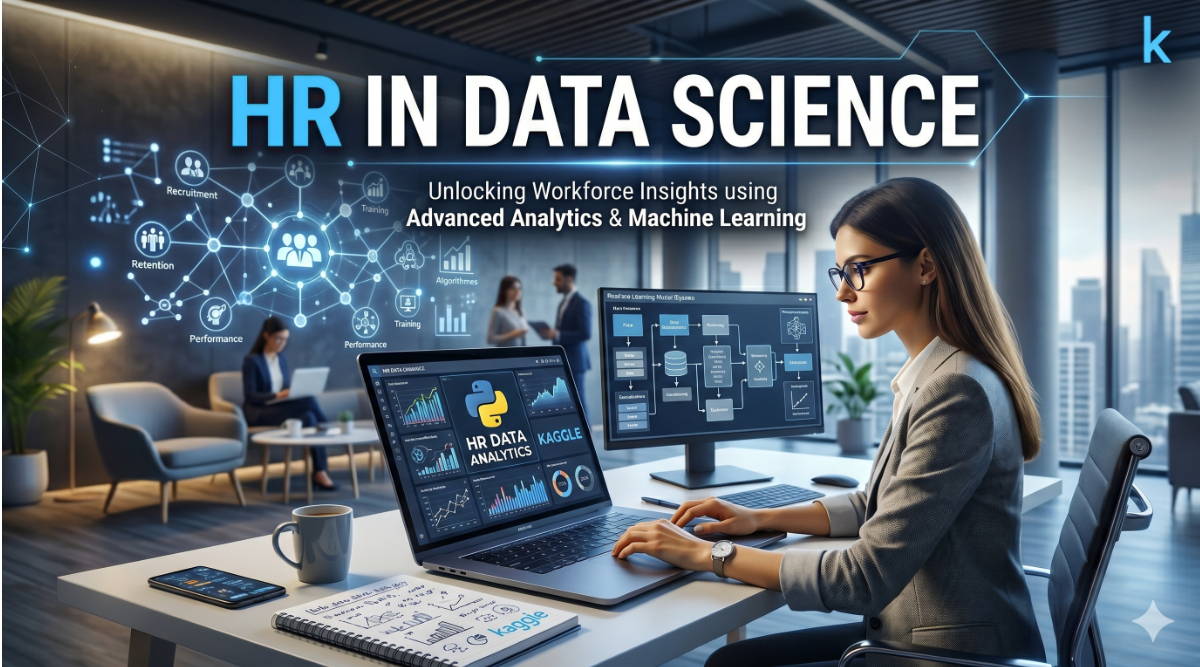

# **PREDICTING JOB CHANGE INTENTION OF DATA SCIENTIST CANDIDATES**


---

## 1. Introduction

### 1.1 Problem Statement

Many companies invest heavily in training and recruiting data scientists, only to lose them to other employers shortly after. The challenge is identifying **which candidates are genuinely looking for a new job** — before they leave.

This notebook builds a **binary classification model** to predict whether a data science candidate is actively seeking a job change, using background and training data collected during a company's hiring program.

---

### 1.2 Motivation

From an **HR perspective**, knowing who is likely to leave allows a company to:
- Proactively retain high-value talent
- Prioritize recruitment resources more efficiently
- Understand which employee profiles are at higher flight risk

### 1.3 Stakeholders

The primary stakeholders benefiting from this predictive model include Chief Human Resources Officers (CHROs), talent acquisition managers, and workforce analytics teams aiming to optimize retention strategies.

### 1.4 Research Hypothesis

The project also tests three specific **hypothesis**

H1: Job mobility history, measured by last_new_job, is a strong indicator of a candidate's propensity to leave.

H2: Work experience characteristics, including total experience and relevant experience, contribute significantly to predicting employee attrition.

H3: Regional development conditions, measured by `city_development_index`, contribute significantly to predicting employee attrition.

---

## 2. Data Understanding

### 2.1 Dataset

| Item | Detail |
|------|--------|
| **Source** | [Kaggle — Job Change of Data Scientists](https://www.kaggle.com/arashnic/hr-analytics-job-change-of-data-scientists) |
| **Train file** | `aug_train.csv` — labeled data used for modeling |
| **Test file** | `aug_test.csv` — unlabeled data for final prediction |
| **Train size** | ~19,158 rows |
| **Test size** | ~2,129 rows |

---

### 2.2 Key Variables

| Variable | Type | Description |
|---|---|---|
| `city_development_index` | Numeric | Development level of candidate's city (0–1) |
| `last_new_job` | Categorical | Years since last job change |
| `experience` | Categorical | Years of total work experience |
| `education_level` | Categorical | Highest education attained |
| `enrolled_university` | Categorical | Current university enrollment status |
| `relevent_experience` | Categorical | Has relevant data science experience? |
| `company_size` | Categorical | Size of current employer |
| `company_type` | Categorical | Type of current employer |
| `training_hours` | Numeric | Total training hours completed |
| `gender`, `major_discipline` | Categorical | Demographics |

---

### 2.3 Target Variable

| Value | Meaning | Proportion |
|---|---|---|
| `0` | Candidate is **NOT** looking for a job change | ~75% |
| `1` | Candidate **IS** looking for a job change | ~25% |

>  The dataset is **imbalanced** (75/25). This affects our choice of evaluation metric — we prioritize **Recall** for class 1 to minimize missed detections.

---

### 2.4 Libraries Used

| Library | Purpose |
|---|---|
| `pandas`, `numpy` | Data manipulation and numerical computing |
| `matplotlib`, `seaborn` | Data visualization |
| `scikit-learn` | Machine learning models, preprocessing, and evaluation |

---

##  Table of Contents

| # | Section | Description |
|---|---------|-------------|
| 3 | [Import Libraries](#3-import-libraries) | Load all required packages |
| 4 | [Data Preprocessing](#4-data-preprocessing) | Load data & handle missing values |
| 5 | [Exploratory Data Analysis (EDA)](#5-eda) | Understand distributions & relationships |
| 6 | [Feature Engineering](#6-feature-engineering) | Encode & scale features for modeling |
| 7 | [Modelling & Evaluation (CV)](#7-modelling) | Train 3 models, tune, compare on CV |
| 8 | [Final Model Evaluation](#8-final-evaluation) | Evaluate best model on held-out val set |
| 9 | [Prediction & Conclusion](#9-prediction) | Predict test set, conclude, recommend |

---

<a id='3-import-libraries'></a>
## 3. Import Libraries

In [1]:
# ── Standard data science libraries ─────────────────────────────────────────
import pandas as pd          # tabular data manipulation (DataFrame)
import numpy as np           # numerical computing, array handling

# ── Visualization ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt   # basic plotting
import seaborn as sns             # statistical visualization, nicer than matplotlib

# ── Sklearn: preprocessing ───────────────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler      # normalize to range [0, 1]

# ── Sklearn: model selection & cross-validation ──────────────────────────────
from sklearn.model_selection import (
    train_test_split,        # split into train / validation sets
    StratifiedKFold,         # k-fold preserving class ratio (important for imbalanced data)
    cross_validate,          # evaluate model across multiple folds
    RandomizedSearchCV       # find best hyperparameters via random search
)

# ── Sklearn: classification models ───────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# ── Sklearn: evaluation metrics ──────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# ── Suppress warnings for cleaner output ─────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

print(" All libraries imported successfully.")

 All libraries imported successfully.


<a id='4-data-preprocessing'></a>
## 4. Data Preprocessing

### 4.1 Load Data

In [2]:
train = pd.read_csv('aug_train.csv')
test  = pd.read_csv('aug_test.csv')

print(f"Train shape : {train.shape}")
print(f"Test  shape : {test.shape}")
train.head(3)

Train shape : (19158, 14)
Test  shape : (2129, 13)


,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0


### 4.2 Initial Inspection — Missing Values

In [3]:
# View total missing count and percentage per column
print("=== TRAIN — Missing Values ===")
missing_train = pd.DataFrame({
    'Missing Count': train.isnull().sum(),
    'Missing %': (train.isna().mean() * 100).round(2)
})
print(missing_train[missing_train['Missing Count'] > 0])

=== TRAIN — Missing Values ===
                     Missing Count  Missing %
gender                        4508      23.53
enrolled_university            386       2.01
education_level                460       2.40
major_discipline              2813      14.68
experience                      65       0.34
company_size                  5938      30.99
company_type                  6140      32.05
last_new_job                   423       2.21


### 4.3 Drop `city` Column

**Reason**: `city` is just an identifier (e.g. `city_103`) — it carries no direct information.
Instead, `city_development_index` (CDI) already summarizes the city's economic development level as a continuous numeric variable, which is more suitable for modeling.

In [4]:
train.drop(columns=['city'], inplace=True)
test.drop(columns=['city'],  inplace=True)
print("Dropped 'city' column from both train and test.")

Dropped 'city' column from both train and test.


### 4.4 Data Cleaning — Train Set

> **Missing value imputation principles**:
> - Use **`fillna('category_name')`** for categorical variables when missingness has its own meaning (e.g., missing gender = "Prefer not to say").
> - Use **`fillna(mode())`** when missingness is random with no special meaning → fill with the most frequent value.
> - Use **`fillna('Unknown')`** when the reason for missingness is unclear and you don't want to introduce bias from the mode.

#### 4.4.1 Gender

In [5]:
# Reason for fillna('Prefer not to say'):
# → Missing in the gender column does not mean the person has no gender.
# → It is a personal choice: the respondent chose not to disclose.
# → Creates a new category instead of dropping or using the mode → preserves original meaning.
print("Before:", train['gender'].unique())
train['gender'] = train['gender'].fillna('Prefer not to say')
print("After :", train['gender'].unique())

Before: ['Male' nan 'Female' 'Other']
After : ['Male' 'Prefer not to say' 'Female' 'Other']


#### 4.4.2 Enrolled University

In [6]:
# Step 1: Normalize labels — 'no_enrollment' and 'No enrollment' mean the same thing
train['enrolled_university'] = train['enrolled_university'].replace({'no_enrollment': 'No enrollment'})

# Step 2: Fill missing with mode()
# → Reason: missingness here is random (respondent skipped the question)
# → mode() = most frequent value → minimally impacts the distribution
train['enrolled_university'] = train['enrolled_university'].fillna(train['enrolled_university'].mode()[0])
print("Unique values:", train['enrolled_university'].unique())

Unique values: ['No enrollment' 'Full time course' 'Part time course']


#### 4.4.3 Education Level

In [7]:
# Reason for fillna(mode()):
print("Before:", train['education_level'].unique())
train['education_level'] = train['education_level'].fillna(train['education_level'].mode()[0])
print("After :", train['education_level'].unique())

Before: ['Graduate' 'Masters' 'High School' nan 'Phd' 'Primary School']
After : ['Graduate' 'Masters' 'High School' 'Phd' 'Primary School']


#### 4.4.4 Major Discipline

In [8]:
# Reason for fillna('No Major'):
# → Many candidates have no specific major (e.g., general studies, undeclared)
# → 'No Major' is a meaningful category, not erroneous data.
# → mode() is not used because 'No Major' is a more reasonable interpretation.
print("Before:", train['major_discipline'].unique())
train['major_discipline'] = train['major_discipline'].fillna('No Major')
print("After :", train['major_discipline'].unique())

Before: ['STEM' 'Business Degree' nan 'Arts' 'Humanities' 'No Major' 'Other']
After : ['STEM' 'Business Degree' 'No Major' 'Arts' 'Humanities' 'Other']


#### 4.4.5 Experience

In [9]:
# Reason for fillna(mode()):
# → Experience is an ordinal text variable ('<1', '1', ..., '>20').
# → Missingness is random → use mode() (most frequent value) to fill.
print("Before unique:", train['experience'].unique())
train['experience'] = train['experience'].fillna(train['experience'].mode()[0])
print("After  unique:", train['experience'].unique())

Before unique: ['>20' '15' '5' '<1' '11' '13' '7' '17' '2' '16' '1' '4' '10' '14' '18'
 '19' '12' '3' '6' '9' '8' '20' nan]
After  unique: ['>20' '15' '5' '<1' '11' '13' '7' '17' '2' '16' '1' '4' '10' '14' '18'
 '19' '12' '3' '6' '9' '8' '20']


#### 4.4.6 Company Size & Company Type

In [10]:
# Reason for fillna('Unknown') for both:
# → Candidates missing company_size/company_type may be unemployed,
#   freelancing, or recent graduates — they have no current company.
# → 'Unknown' is a meaningful standalone category, avoiding mode-induced bias.
train['company_size'] = train['company_size'].fillna('Unknown')
train['company_type'] = train['company_type'].fillna('Unknown')

#### 4.4.7 Last New Job

In [11]:
# Reason for fillna('Unknown'):
# → It is unclear whether the missing person has never changed jobs or simply forgot to answer.
# → Using 'Unknown' keeps this group separate, avoiding spurious influence on the model.
print("Before:", train['last_new_job'].unique())
train['last_new_job'] = train['last_new_job'].fillna('Unknown')
print("After :", train['last_new_job'].unique())

Before: ['1' '>4' 'never' '4' '3' '2' nan]
After : ['1' '>4' 'never' '4' '3' '2' 'Unknown']


### 4.5 Data Cleaning — Test Set

In [12]:
# Apply the same logic as train — consistency is paramount
test['enrolled_university'] = test['enrolled_university'].replace({'no_enrollment': 'No enrollment'})
test['gender']              = test['gender'].fillna('Prefer not to say')
test['company_size']        = test['company_size'].fillna('Unknown')
test['company_type']        = test['company_type'].fillna('Unknown')
test['last_new_job']        = test['last_new_job'].fillna('Unknown')
test['major_discipline']    = test['major_discipline'].fillna('No Major')

# Use mode() for remaining variables
for col in ['enrolled_university', 'education_level', 'experience']:
    test[col] = test[col].fillna(test[col].mode()[0])

print(f"Missing values after cleaning — Test: {test.isnull().sum().sum()}")
print(f"Test shape: {test.shape}")
test.head(3)

Missing values after cleaning — Test: 0
Test shape: (2129, 12)


,enrollee_id,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours
0,32403,0.827,Male,Has relevent experience,Full time course,Graduate,STEM,9,<10,Unknown,1,21
1,9858,0.920,Female,Has relevent experience,No enrollment,Graduate,STEM,5,Unknown,Pvt Ltd,1,98
2,31806,0.624,Male,No relevent experience,No enrollment,High School,No Major,<1,Unknown,Pvt Ltd,never,15


<a id='5-eda'></a>
## 5. Exploratory Data Analysis (EDA)

> **Goal**: Understand data distributions, detect patterns related to the target variable, and test the hypothesis about `last_new_job`.

### 5.1 Target Variable Distribution

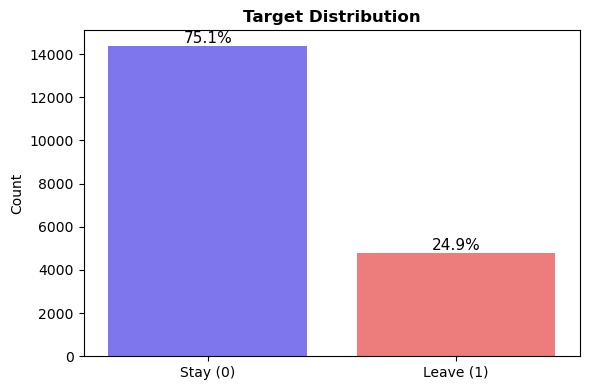

In [13]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(
    x='target',
    data=train,
    palette=['#6C63FF', '#FF6B6B']
)

ax.set_title('Target Distribution', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Count')
ax.set_xticklabels(['Stay (0)', 'Leave (1)'])

total = len(train)

for p in ax.patches:
    pct = 100 * p.get_height() / total

    ax.annotate(
        f'{pct:.1f}%',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.tight_layout()
plt.show()

**Interpretation:**
- The target is clearly **imbalanced**: ~75% stay (class 0) and ~25% want to change jobs (class 1).
- This imbalance affects the choice of evaluation metric: raw Accuracy should be avoided since a model can reach 75% simply by always predicting class 0.
- **Priority metric**: ROC-AUC and Recall (class 1) — measuring the ability to correctly identify candidates who plan to leave.

### 5.2 Key Variable: `last_new_job` 

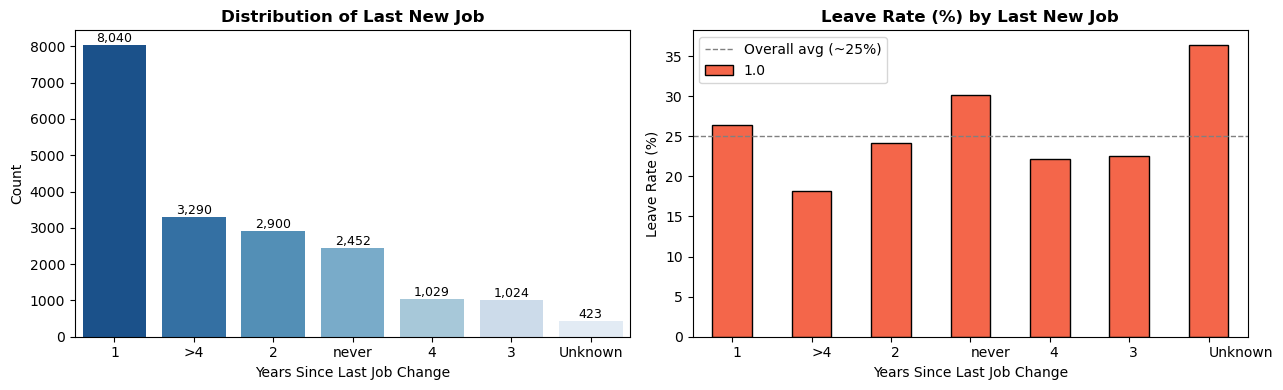


── Leave Rate by Last New Job (%) ──
target         0.0   1.0
last_new_job            
1             73.6  26.4
2             75.9  24.1
3             77.4  22.6
4             77.8  22.2
>4            81.8  18.2
Unknown       63.6  36.4
never         69.9  30.1


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Plot 1: Distribution of last_new_job
order = train['last_new_job'].value_counts().index
sns.countplot(x='last_new_job', data=train, order=order, palette='Blues_r', ax=axes[0])
axes[0].set_title('Distribution of Last New Job', fontweight='bold')
axes[0].set_xlabel('Years Since Last Job Change')
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

# Plot 2: Leave rate by last_new_job
leave_by_job = pd.crosstab(train['last_new_job'], train['target'], normalize='index') * 100
leave_by_job[1].reindex(order).plot(
    kind='bar',
    ax=axes[1],
    color='#F4664A',
    edgecolor='black'
)

axes[1].set_title('Leave Rate (%) by Last New Job', fontweight='bold')
axes[1].set_xlabel('Years Since Last Job Change')
axes[1].set_ylabel('Leave Rate (%)')

plt.setp(
    axes[1].get_xticklabels(),
    rotation= 0,
    ha='left'
)

axes[1].axhline(
    y=25,
    color='gray',
    linestyle='--',
    linewidth=1,
    label='Overall avg (~25%)'
)
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_last_new_job.png', dpi=130, bbox_inches='tight')
plt.show()

# Cross-tabulation
print("\n── Leave Rate by Last New Job (%) ──")
print((pd.crosstab(train['last_new_job'], train['target'], normalize='index') * 100).round(1))

**Interpretation:**
- **Most candidates** last changed jobs 1 year ago (8,463 people), followed by the >4 year group.
- **Hypothesis partially supported**: candidates who changed jobs recently (1 year ago) have a leave rate of 26.4%, higher than the >4 year group (18.2%).
- **Interesting finding**: the `never` group (never changed jobs) has the highest leave rate (~30%), likely consisting of first-time job seekers (fresh graduates).
- **Conclusion**: `last_new_job` is an important predictor — it will be prioritized in the feature importance analysis.

### 5.3 Numeric Features

── Descriptive Statistics ──
       city_development_index  training_hours
count                19158.00        19158.00
mean                     0.83           65.37
std                      0.12           60.06
min                      0.45            1.00
25%                      0.74           23.00
50%                      0.90           47.00
75%                      0.92           88.00
max                      0.95          336.00

── Correlation with Target ──
city_development_index   -0.342
training_hours           -0.022
dtype: float64


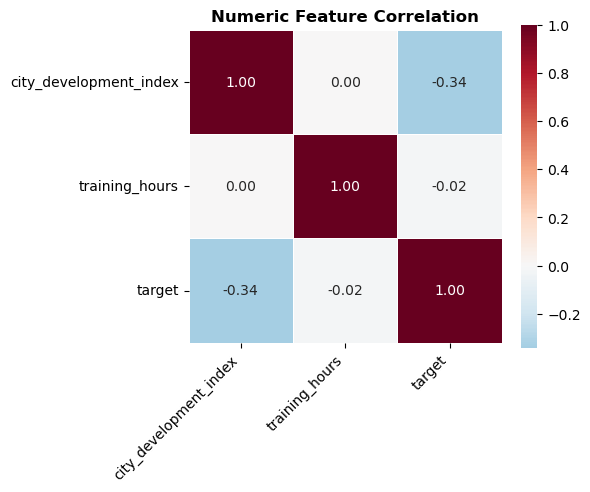

In [15]:
print("── Descriptive Statistics ──")
print(train[['city_development_index', 'training_hours']].describe().round(2))
print("\n── Correlation with Target ──")
print(train[['city_development_index', 'training_hours']].corrwith(train['target']).round(3))


# Heatmap: correlation
num_cols = ['city_development_index', 'training_hours', 'target']
plt.figure(figsize=(6, 5))

sns.heatmap(
    train[num_cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    square=True
)
plt.xticks(rotation=45, ha='right')
plt.title('Numeric Feature Correlation', fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:**
- **`city_development_index`** has a moderate negative correlation with the target (r = −0.342): candidates from less developed cities tend to want to change jobs more — possibly due to limited local opportunities.
- **`training_hours`** has almost no correlation with the target (r = −0.022): the number of training hours does not predict the intention to change jobs.
- **Conclusion**: This suggests that city development may have some predictive value, whereas training hours contribute little explanatory power.

### 5.4 Categorical Features — Leave Rate Analysis

In [16]:
cat_cols = ['gender', 'relevent_experience', 'enrolled_university',
            'education_level', 'major_discipline', 'experience',
            'company_size', 'company_type']

print("── Leave Rate (mean target) by Feature ──")
for col in cat_cols:
    print(f"\n{col}:")
    print(train.groupby(col)['target'].mean().round(3).sort_values(ascending=False))

── Leave Rate (mean target) by Feature ──

gender:
gender
Prefer not to say    0.308
Female               0.263
Other                0.262
Male                 0.228
Name: target, dtype: float64

relevent_experience:
relevent_experience
No relevent experience     0.338
Has relevent experience    0.215
Name: target, dtype: float64

enrolled_university:
enrolled_university
Full time course    0.381
Part time course    0.252
No enrollment       0.214
Name: target, dtype: float64

education_level:
education_level
Graduate          0.278
Masters           0.214
High School       0.195
Phd               0.140
Primary School    0.133
Name: target, dtype: float64

major_discipline:
major_discipline
Other              0.268
Business Degree    0.263
STEM               0.262
Humanities         0.211
Arts               0.209
No Major           0.199
Name: target, dtype: float64

experience:
experience
<1     0.454
1      0.424
3      0.353
2      0.332
4      0.326
7      0.295
5      0.288
6     

Based on the table above, the 3 variables with the most distinct differences in leave rate are:

| Variable | Evidence |
|---|---|
| **experience** | Leave rate drops from 45.4% (< 1 year) to 15.7% (> 20 years) |
| **relevent_experience** | 33.8% (no relevant experience) vs 21.5% (has relevant experience) |
| **enrolled_university** | 38.1% (full-time enrolled) vs 21.4% (not enrolled) |

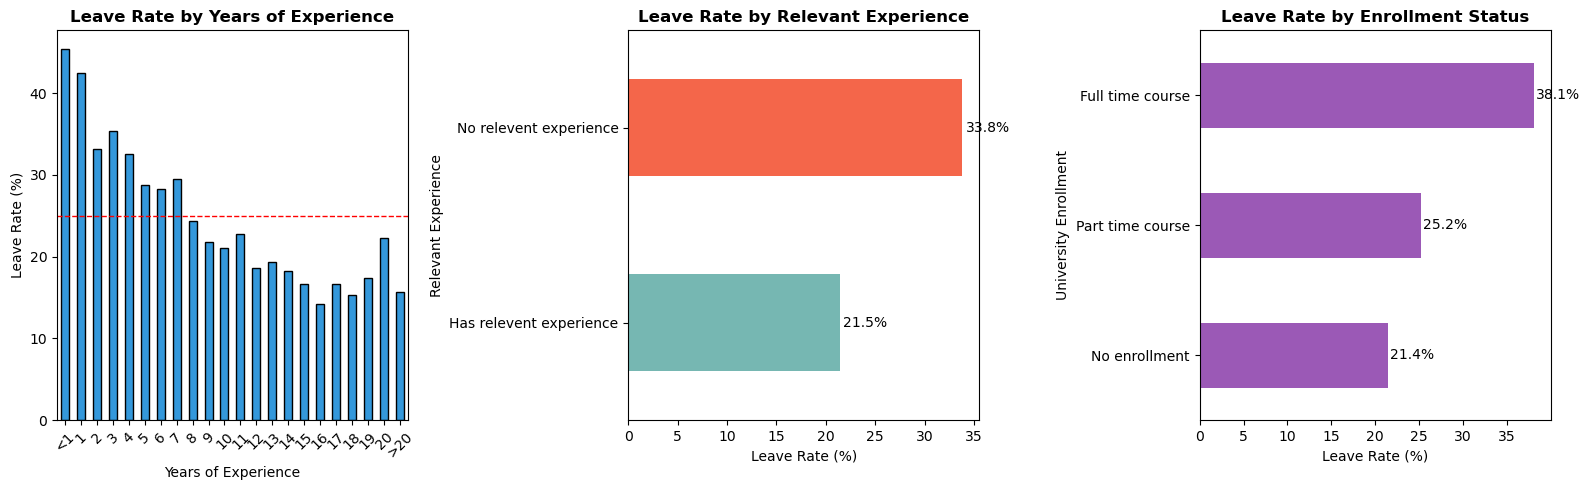

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Plot 1: Experience vs Leave Rate ─────────────────────────────────────────
exp_order = ['<1','1','2','3','4','5','6','7','8','9','10',
             '11','12','13','14','15','16','17','18','19','20','>20']
leave_by_exp = train.groupby('experience')['target'].mean().reindex(exp_order) * 100
leave_by_exp.plot(kind='bar', ax=axes[0], color='#3498db', edgecolor='black')
axes[0].set_title('Leave Rate by Years of Experience', fontweight='bold')
axes[0].set_xlabel('Years of Experience')
axes[0].set_ylabel('Leave Rate (%)')
axes[0].axhline(y=25, color='red', linestyle='--', linewidth=1)
axes[0].tick_params(axis='x', rotation=45)

# ── Plot 2: Relevant Experience vs Leave Rate ─────────────────────────────────
leave_by_rel = train.groupby('relevent_experience')['target'].mean() * 100
leave_by_rel.plot(kind='barh', ax=axes[1], color=['#76B7B2', '#F4664A'])
axes[1].set_title('Leave Rate by Relevant Experience', fontweight='bold')
axes[1].set_xlabel('Leave Rate (%)')
axes[1].set_ylabel('Relevant Experience')
# Add value labels
for i, v in enumerate(leave_by_rel):
    axes[1].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=10)

# ── Plot 3: Enrolled University vs Leave Rate ─────────────────────────────────
leave_by_enr = train.groupby('enrolled_university')['target'].mean().sort_values() * 100
leave_by_enr.plot(kind='barh', ax=axes[2], color='#9b59b6')
axes[2].set_title('Leave Rate by Enrollment Status', fontweight='bold')
axes[2].set_xlabel('Leave Rate (%)')
axes[2].set_ylabel('University Enrollment')
for i, v in enumerate(leave_by_enr):
    axes[2].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

**Interpretation:**

- **Experience**: There is a clear negative relationship — candidates with less experience are more likely to change jobs. Leave rate drops steadily from 45.4% (<1 year) to 15.7% (>20 years). Entry-level workers have not yet built long-term commitment.

- **Relevant Experience**: Candidates without relevant experience (33.8%) are more likely to change jobs than those with relevant experience (21.5%). They may be looking for roles that better match their newly acquired skills.

- **Enrolled University**: Full-time students have the highest leave rate (38.1%), as they are in a transitional phase seeking better opportunities after graduation. Those not enrolled (21.4%) are more stable.

<a id='6-feature-engineering'></a>
## 6. Feature Engineering

> **Goal**: Convert all text/categorical variables into numeric format so that models can process them.

### Encoding Strategy

| Encoding Type | When to Use | Applied Features |
|---|---|---|
| **Binary Encode** | Variable with only 2 Yes/No values | `relevent_experience` |
| **Ordinal Encode** | Variable with a clear natural order | `experience`, `education_level`, `company_size`, `last_new_job` |
| **One-Hot Encode** | Nominal categorical with no order | `gender`, `major_discipline`, `company_type`, `enrolled_university` |

### Step 1 — Fix Excel-Corrupted Values

In [18]:
# '10/49' is an Excel auto-format bug that converted '10-49' into a date-like string
# → Must be fixed before encoding, otherwise the mapping will produce NaN
train['company_size'] = train['company_size'].replace('10/49', '10-49')
test['company_size']  = test['company_size'].replace('10/49', '10-49')
print('Train company_size unique:', sorted(train['company_size'].unique()))

Train company_size unique: ['10-49', '100-500', '1000-4999', '10000+', '50-99', '500-999', '5000-9999', '<10', 'Unknown']


### Step 2 — Binary Encode: `relevent_experience`

**Reason for Binary Encoding**: The variable has only 2 values (yes/no). Encoding as 1/0 is straightforward, adds no extra columns, and preserves the original meaning.

In [19]:
exp_map = {'Has relevent experience': 1, 'No relevent experience': 0}
train['relevent_experience'] = train['relevent_experience'].map(exp_map)
test['relevent_experience']  = test['relevent_experience'].map(exp_map)
print("Unique values:", train['relevent_experience'].unique())

Unique values: [1 0]


### Step 3 — Ordinal Encode: `experience`

**Reason for Ordinal Encoding**: `experience` has a clear natural order (`<1` < `1` < `2` < ... < `>20`). Integers let the model capture the linear relationship (more years of experience = higher number).

In [20]:
# '<1' → 0  |  '1'–'20' → integer  |  '>20' → 21
def encode_experience(val):
    if pd.isna(val): return np.nan
    if val == '<1':  return 0
    if val == '>20': return 21
    return int(val)

train['experience'] = train['experience'].apply(encode_experience)
test['experience']  = test['experience'].apply(encode_experience)
print(f"Train NaN after: {train['experience'].isna().sum()} | Test NaN: {test['experience'].isna().sum()}")

Train NaN after: 0 | Test NaN: 0


### Step 4 — Ordinal Encode: `last_new_job` *(key feature)*

**Reason for Ordinal Encoding**: This variable measures years since the last job change — it has a natural order. `Unknown` is assigned -1 to distinguish it from valid values.

In [21]:
mapping = {
    'Unknown': -1,   
    'never':    0,   
    '1':        1,
    '2':        2,
    '3':        3,
    '4':        4,
    '>4':       5    # changed jobs more than 4 years ago
}
train['last_new_job'] = train['last_new_job'].map(mapping)
test['last_new_job']  = test['last_new_job'].map(mapping)
print(f"Train NaN: {train['last_new_job'].isna().sum()} | Test NaN: {test['last_new_job'].isna().sum()}")

Train NaN: 0 | Test NaN: 0


### Step 5 — Ordinal Encode: `education_level`

**Reason for Ordinal Encoding**: Education has a clear hierarchy (Primary School < High School < Graduate < Masters < PhD). Integers let the model capture this ordering.

In [22]:
edu_map = {
    'Primary School': 0,
    'High School':    1,
    'Graduate':       2,
    'Masters':        3,
    'Phd':            4
}
train['education_level'] = train['education_level'].map(edu_map)
test['education_level']  = test['education_level'].map(edu_map)
print(f"Train NaN: {train['education_level'].isna().sum()} | Test NaN: {test['education_level'].isna().sum()}")

Train NaN: 0 | Test NaN: 0


### Step 6 — Ordinal Encode: `company_size`

**Reason for Ordinal Encoding**: Company size has a natural order (<10 < 10-49 < ... < 10000+). `Unknown` = 0 to distinguish it from the smallest valid group.

In [23]:
size_map = {
    'Unknown':   0,
    '<10':       1,
    '10-49':     2,
    '50-99':     3,
    '100-500':   4,
    '500-999':   5,
    '1000-4999': 6,
    '5000-9999': 7,
    '10000+':    8
}
train['company_size'] = train['company_size'].map(size_map)
test['company_size']  = test['company_size'].map(size_map)
print(f"Train NaN: {train['company_size'].isna().sum()} | Test NaN: {test['company_size'].isna().sum()}")

Train NaN: 0 | Test NaN: 0


### Step 7 — One-Hot Encode: Nominal Categorical Features

**Reason for One-Hot Encoding**: `gender`, `major_discipline`, `company_type`, and `enrolled_university` **have no natural order** — you cannot say STEM > Arts or Pvt Ltd > NGO. Using Ordinal would mislead the model into treating higher numbers as "greater".

> **Important**: You must **combine train + test before** calling `get_dummies()`.
> **Why?** If encoded separately, train might have a `gender_Other` column that test doesn't (or vice versa) → mismatched column counts → prediction errors.

In [24]:
# Mark rows to split again after encoding
train['_is_train'] = 1
test['_is_train']  = 0

# Combine to ensure identical columns after get_dummies
combined = pd.concat([train, test], axis=0, ignore_index=True)

# =====================================================
# QUAN TRỌNG: Tách enrolled_university ra xử lý riêng
# =====================================================

#
combined = pd.get_dummies(
    combined,
    columns=['gender', 'major_discipline', 'company_type'],
    drop_first=False,
    dtype=int
)

#
combined = pd.get_dummies(
    combined,
    columns=['enrolled_university'],
    prefix='enrolled',          # ← THÊM DÒNG NÀY
    drop_first=False,
    dtype=int
)

# Split back into train and test
train_fe = combined[combined['_is_train'] == 1].drop(columns=['_is_train']).reset_index(drop=True)
test_fe  = combined[combined['_is_train'] == 0].drop(columns=['_is_train', 'target']).reset_index(drop=True)

print('Train shape after encoding:', train_fe.shape)
print('Test  shape after encoding:', test_fe.shape)

Train shape after encoding: (19158, 29)
Test  shape after encoding: (2129, 28)


### Step 8 — Scale Numeric Features (MinMaxScaler)

**Reason for Scaling**:
- `city_development_index` already lies in [0, 1], but `training_hours` can reach up to 336.
- This scale difference affects models sensitive to magnitude, such as Logistic Regression (gradient descent).
- **MinMaxScaler** (rescales to [0, 1]) is used because there are no extreme outliers.

> **Important**: Only `fit_transform` on **train**, then only `transform` on **test**.
> Fitting on the test set would let the model "peek" at test data → **data leakage** → inflated results.

In [25]:
scaler = MinMaxScaler()
scale_cols = ['city_development_index', 'training_hours']

# fit_transform: learn min/max from train, then scale train
train_fe[scale_cols] = scaler.fit_transform(train_fe[scale_cols])

# transform only: use TRAIN's min/max to scale test → prevents data leakage
test_fe[scale_cols]  = scaler.transform(test_fe[scale_cols])

print("Scaling done.")
print(f"city_development_index range (train): [{train_fe['city_development_index'].min():.3f}, {train_fe['city_development_index'].max():.3f}]")
print(f"training_hours range (train): [{train_fe['training_hours'].min():.3f}, {train_fe['training_hours'].max():.3f}]")

Scaling done.
city_development_index range (train): [0.000, 1.000]
training_hours range (train): [0.000, 1.000]


### Step 9 — Drop ID & Final Check

In [26]:
train_fe.drop(columns=['enrollee_id'], inplace=True)
test_ids = test_fe['enrollee_id'].copy()   # save IDs for submission
test_fe.drop(columns=['enrollee_id'], inplace=True)

print(f"Missing in train_fe: {train_fe.isnull().sum().sum()}")
print(f"Missing in test_fe : {test_fe.isnull().sum().sum()}")
print(f"\nFinal train shape  : {train_fe.shape}")
print(f"Final test  shape  : {test_fe.shape}")
train_fe.head(3)

Missing in train_fe: 0
Missing in test_fe : 0

Final train shape  : (19158, 28)
Final test  shape  : (2129, 27)


,city_development_index,relevent_experience,education_level,experience,company_size,last_new_job,training_hours,target,gender_Female,gender_Male,...,company_type_Early Stage Startup,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd,company_type_Unknown,enrolled_Full time course,enrolled_No enrollment,enrolled_Part time course
0,0.942116,1,2,21,0,1,0.104478,1.0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0.654691,0,2,15,3,5,0.137313,0.0,0,1,...,0,0,0,0,0,1,0,0,1,0
2,0.351297,0,2,5,0,0,0.244776,0.0,0,0,...,0,0,0,0,0,0,1,1,0,0


### Step 10 — Train / Validation Split

In [27]:
X = train_fe.drop(columns=['target'])
y = train_fe['target']

# stratify=y: ensures the 75/25 class ratio is preserved in both train and val
# → Avoids the case where the val set has too few class 1 samples
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_train: {X_train.shape} | X_val: {X_val.shape}")
print(f"y_train class balance: {y_train.value_counts().to_dict()}")
print(f"y_val   class balance: {y_val.value_counts().to_dict()}")

X_train: (15326, 27) | X_val: (3832, 27)
y_train class balance: {0.0: 11504, 1.0: 3822}
y_val   class balance: {0.0: 2877, 1.0: 955}


<a id='7-modelling'></a>
## 7. Modelling & Evaluation

### 7.1 Strategy Overview

All model selection and tuning is performed **on X_train only**, using cross-validation. The validation set (X_val) is kept completely "unseen" until Section 8.

| Model | Approach | Handling Imbalance |
|---|---|---|
| **Logistic Regression** | Fixed params (linear baseline) | `class_weight='balanced'` |
| **Random Forest** | `RandomizedSearchCV` 5-fold CV | `class_weight='balanced'` |
| **Gradient Boosting** | `RandomizedSearchCV` 5-fold CV | `min_samples_leaf` constraint |

**Priority Metric: Recall (class 1)**
> In the HR context, missing a candidate who intends to leave (False Negative) is more costly than a false alarm (False Positive). HR may waste retention resources on the wrong person, but will not lose actual talent.

**Why Stratified K-Fold?**
> The dataset is class-imbalanced (75/25). Standard KFold may produce folds with very few or no class 1 samples → unreliable metrics. StratifiedKFold ensures each fold maintains the 75/25 ratio.

### 7.2 Cross-Validation Setup

In [28]:
# 5-fold StratifiedKFold
# n_splits=5: 5 folds → each iteration uses 80% train, 20% validate within X_train
# shuffle=True: shuffle data before splitting to avoid order-based bias
# random_state=42: reproducible results
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("Cross-validation strategy: StratifiedKFold(n_splits=5)")

Cross-validation strategy: StratifiedKFold(n_splits=5)


### 7.3 Model 1 — Logistic Regression (Baseline)

**Why use Logistic Regression as a baseline?**
- It is the simplest linear model for classification tasks.
- Easy to interpret (coefficients = degree of influence per feature).
- If more complex models don't significantly improve results, the baseline may be sufficient.

**Hyperparameter explanations:**
- `class_weight='balanced'`: automatically upweights class 1 (minority) — prevents the model from being biased toward class 0.
- `C=0.1`: strong regularization → reduces overfitting, suitable when many features exist after one-hot encoding.
- `max_iter=1000`: increases maximum iterations to ensure gradient descent converges.

In [29]:
lr_model = LogisticRegression(
    max_iter=1000,           # enough iterations to converge
    random_state=42,
    class_weight='balanced', # compensate for 75/25 class imbalance
    C=0.1                    # strong regularization to prevent overfitting
)

cv_results_lr = cross_validate(
    lr_model, X_train, y_train,
    cv=CV,
    scoring={'roc_auc': 'roc_auc', 'f1': 'f1', 'recall': 'recall'}
)

lr_cv_auc    = cv_results_lr['test_roc_auc']
lr_cv_f1     = cv_results_lr['test_f1']
lr_cv_recall = cv_results_lr['test_recall']

print('Logistic Regression — 5-Fold CV Results (X_train only)')
print(f'  ROC-AUC : {lr_cv_auc.mean():.4f} ± {lr_cv_auc.std():.4f}')
print(f'  F1      : {lr_cv_f1.mean():.4f} ± {lr_cv_f1.std():.4f}')
print(f'  Recall  : {lr_cv_recall.mean():.4f} ± {lr_cv_recall.std():.4f}')

Logistic Regression — 5-Fold CV Results (X_train only)
  ROC-AUC : 0.7698 ± 0.0084
  F1      : 0.5632 ± 0.0126
  Recall  : 0.7232 ± 0.0168


### 7.4 Model 2 — Random Forest (RandomizedSearchCV)

**What is Random Forest?**
Random Forest builds many Decision Trees, each trained on a random sample of the data and a random subset of features. The final prediction is a majority vote from all trees → more stable and less prone to overfitting than a single tree.

**Why RandomizedSearchCV instead of GridSearchCV?**
- GridSearchCV tries **all** combinations: 3×4×3×3×2 = 216 combinations × 5 folds = 1,080 fits → very slow.
- RandomizedSearchCV tries only **20 random combinations** × 5 folds = 100 fits → ~10x faster, with comparable results.

**Param grid explanation:**

In [30]:
rf_param_dist = {
    'n_estimators'     : [50, 100, 150],   # number of trees in the forest
    'max_depth'        : [5, 10, 20, None],# max depth (None = unlimited)
    'min_samples_split': [2, 5, 10],       # minimum samples required to split a node
    'min_samples_leaf' : [1, 2, 4],        # minimum samples at a leaf node (prevents overfitting)
    'max_features'     : ['sqrt', 'log2'], # number of features considered per split
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=50,       
    scoring='roc_auc',   # optimize by ROC-AUC
    cv=CV,               # use the same CV strategy defined earlier
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

print('\nRandom Forest — Best Results')
print(f'  Best ROC-AUC (CV): {rf_search.best_score_:.4f}')
print(f'  Best Parameters  : {rf_search.best_params_}')

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Random Forest — Best Results
  Best ROC-AUC (CV): 0.7970
  Best Parameters  : {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 10}


In [31]:
# Evaluate best RF on additional metrics
rf_best = rf_search.best_estimator_

rf_cv = cross_validate(
    rf_best, X_train, y_train,
    cv=CV,
    scoring={'f1': 'f1', 'recall': 'recall'}
)

rf_cv_recall = rf_cv['test_recall']
rf_cv_f1     = rf_cv['test_f1']

print('Random Forest (tuned) — 5-Fold CV on X_train')
print(f'  ROC-AUC : {rf_search.best_score_:.4f}')
print(f'  F1      : {rf_cv_f1.mean():.4f} ± {rf_cv_f1.std():.4f}')
print(f'  Recall  : {rf_cv_recall.mean():.4f} ± {rf_cv_recall.std():.4f}')

Random Forest (tuned) — 5-Fold CV on X_train
  ROC-AUC : 0.7970
  F1      : 0.6183 ± 0.0090
  Recall  : 0.7303 ± 0.0098


### 7.5 Model 3 — Gradient Boosting (RandomizedSearchCV)

**What is Gradient Boosting?**
Unlike Random Forest (which builds trees in parallel), Gradient Boosting builds trees **sequentially** — each new tree learns to correct the errors of the previous one. Results are generally better but also more prone to overfitting without careful tuning.

**Key hyperparameter explanations:**
- `learning_rate`: smaller step size → slower but better generalization.
- `subsample < 1.0`: each tree uses only a fraction of the data → reduces overfitting (similar to dropout).
- `min_samples_leaf`: set larger values to control overfitting (in place of class_weight, which GB does not support).

In [32]:
gb_param_dist = {
    'n_estimators' : [50, 100, 150],       # number of trees
    'max_depth'    : [3, 4, 5],            # GB typically uses shallow trees (3-5)
    'learning_rate': [0.03, 0.05, 0.1],    # learning rate — smaller = more stable
    'subsample'    : [0.7, 0.8, 1.0],      # fraction of data used per tree
    'min_samples_leaf': [5, 10, 20],       # controls overfitting in place of class_weight
}

gb_search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_distributions=gb_param_dist,
    n_iter=20,
    cv=CV,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

gb_search.fit(X_train, y_train)

print('\nGradient Boosting — RandomizedSearchCV Results')
print(f'  Best ROC-AUC (CV): {gb_search.best_score_:.4f}')
print(f'  Best Parameters  : {gb_search.best_params_}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Gradient Boosting — RandomizedSearchCV Results
  Best ROC-AUC (CV): 0.7990
  Best Parameters  : {'subsample': 1.0, 'n_estimators': 100, 'min_samples_leaf': 5, 'max_depth': 4, 'learning_rate': 0.05}


In [33]:
gb_best = gb_search.best_estimator_

gb_cv = cross_validate(
    gb_best, X_train, y_train,
    cv=CV,
    scoring={'f1': 'f1', 'recall': 'recall'}
)

gb_cv_f1     = gb_cv['test_f1']
gb_cv_recall = gb_cv['test_recall']

print('Gradient Boosting (tuned) — 5-Fold CV on X_train')
print(f'  ROC-AUC : {gb_search.best_score_:.4f}')
print(f'  F1      : {gb_cv_f1.mean():.4f} ± {gb_cv_f1.std():.4f}')
print(f'  Recall  : {gb_cv_recall.mean():.4f} ± {gb_cv_recall.std():.4f}')

Gradient Boosting (tuned) — 5-Fold CV on X_train
  ROC-AUC : 0.7990
  F1      : 0.5784 ± 0.0171
  Recall  : 0.5631 ± 0.0223


### 7.6 Compare CV Performance

In [34]:
model_map = {
    'Logistic Regression':       lr_model,
    'Random Forest (tuned)':     rf_search.best_estimator_,
    'Gradient Boosting (tuned)': gb_search.best_estimator_,
}

cv_comparison = pd.DataFrame({
    'Model': list(model_map.keys()),
    'CV ROC-AUC': [
        round(lr_cv_auc.mean(), 4),
        round(rf_search.best_score_, 4),
        round(gb_search.best_score_, 4),
    ],
    'CV Recall': [
        round(lr_cv_recall.mean(), 4),
        round(rf_cv_recall.mean(), 4),
        round(gb_cv_recall.mean(), 4),
    ],
    'CV F1': [
        round(lr_cv_f1.mean(), 4),
        round(rf_cv_f1.mean(), 4),
        round(gb_cv_f1.mean(), 4),
    ],
}).set_index('Model')

print('=' * 60)
print('  CV PERFORMANCE COMPARISON (X_train only — no val yet)')
print('=' * 60)
print(cv_comparison.to_string())
print('=' * 60)

  CV PERFORMANCE COMPARISON (X_train only — no val yet)
                           CV ROC-AUC  CV Recall   CV F1
Model                                                   
Logistic Regression            0.7698     0.7232  0.5632
Random Forest (tuned)          0.7970     0.7303  0.6183
Gradient Boosting (tuned)      0.7990     0.5631  0.5784


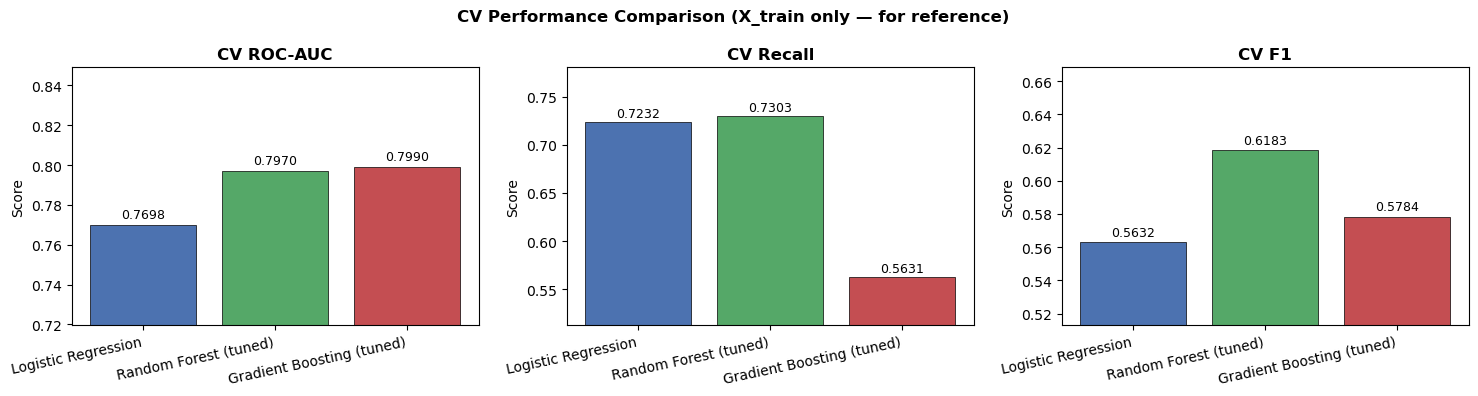

In [36]:
# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['#4C72B0', '#55A868', '#C44E52']
metrics = ['CV ROC-AUC', 'CV Recall', 'CV F1']

for ax, metric in zip(axes, metrics):
    bars = ax.bar(cv_comparison.index, cv_comparison[metric],
                  color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(cv_comparison[metric].min() - 0.05, cv_comparison[metric].max() + 0.05)
    ax.set_ylabel('Score')
    ax.set_xticklabels(cv_comparison.index, rotation=12, ha='right')
    for bar, val in zip(bars, cv_comparison[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)

fig.suptitle('CV Performance Comparison (X_train only — for reference)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('cv_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

**Interpretation:**

All 3 models are compared on the same 5-fold CV to ensure a fair comparison.
Random Forest achieves the highest Recall (0.7303) and F1 (0.6183). Its ROC‑AUC (0.7970) is almost as high as Gradient Boosting (0.7990). Logistic Regression has decent Recall but lower F1 due to poor Precision.

### 7.7 Fit All Models on Full X_train

In [37]:
# Fit all 3 models on the full X_train (needed for comparison in Section 8)
lr_model.fit(X_train, y_train)
rf_best = rf_search.best_estimator_; rf_best.fit(X_train, y_train)
gb_best = gb_search.best_estimator_; gb_best.fit(X_train, y_train)

# Update model_map after fitting
model_map = {
    'Logistic Regression':       lr_model,
    'Random Forest (tuned)':     rf_best,
    'Gradient Boosting (tuned)': gb_best,
}

### 7.8 Full Model Comparison on Validation Set

In [38]:
cv_auc_map = {
    'Logistic Regression':       lr_cv_auc.mean(),
    'Random Forest (tuned)':     rf_search.best_score_,
    'Gradient Boosting (tuned)': gb_search.best_score_,
}

rows = []
for name, model in model_map.items():
    yp   = model.predict(X_val)
    ypr  = model.predict_proba(X_val)[:, 1]
    val_auc = roc_auc_score(y_val, ypr)
    cv_auc  = cv_auc_map[name]
    rows.append({
        'Model':        name,
        'Accuracy':     round(accuracy_score(y_val, yp), 4),
        'Precision':    round(precision_score(y_val, yp), 4),
        'Recall':       round(recall_score(y_val, yp), 4),
        'F1':           round(f1_score(y_val, yp), 4),
        'CV ROC-AUC':   round(cv_auc, 4),
        'Val ROC-AUC':  round(val_auc, 4),
        'Overfit Gap':  round(cv_auc - val_auc, 4),
    })


comparison_df = (
    pd.DataFrame(rows)
    .set_index('Model')
    .sort_values('Recall', ascending=False)
)

print('=' * 90)
print('                FINAL MODEL COMPARISON TABLE (Validation Set)')
print('=' * 90)
print(comparison_df.to_string())
print('=' * 90)

# ==================================================
# SELECT FINAL MODEL BASED ON VALIDATION RECALL
# ==================================================
best_val_name = comparison_df['Recall'].idxmax()
final_model = model_map[best_val_name]

print(f'\nFinal selected model (Validation Recall): {best_val_name}')
print(f'Recall = {comparison_df.loc[best_val_name, "Recall"]:.4f}')
print(f'ROC-AUC = {comparison_df.loc[best_val_name, "Val ROC-AUC"]:.4f}')
print(f'F1 = {comparison_df.loc[best_val_name, "F1"]:.4f}')

                FINAL MODEL COMPARISON TABLE (Validation Set)
                           Accuracy  Precision  Recall      F1  CV ROC-AUC  Val ROC-AUC  Overfit Gap
Model                                                                                               
Random Forest (tuned)        0.7732     0.5306  0.7801  0.6316      0.7970       0.8109      -0.0139
Logistic Regression          0.7239     0.4676  0.7791  0.5844      0.7698       0.7834      -0.0136
Gradient Boosting (tuned)    0.7988     0.5948  0.6042  0.5995      0.7990       0.8168      -0.0178

Final selected model (Validation Recall): Random Forest (tuned)
Recall = 0.7801
ROC-AUC = 0.8109
F1 = 0.6316


**Intepretation**

- Random Forest was selected as the final model because it achieved the highest Recall (0.7801), correctly identifying 78% of actual leavers. While Gradient Boosting had slightly better ROC-AUC (0.8168), its low Recall (0.6042) would miss nearly 40% of high-risk candidates — unacceptable for the business goal.

- All models showed small overfit gaps (≈ -0.014 to -0.018), confirming good generalization. Random Forest's consistent performance across CV and validation sets validates this choice.

<a id='8-final-evaluation'></a>
## 8. Final Model Evaluation on Validation Set

> **Important**: This is the first and only time X_val is used. These results are an **unbiased estimate** of the model's real-world performance on unseen data — it must not be used for tuning or model selection.

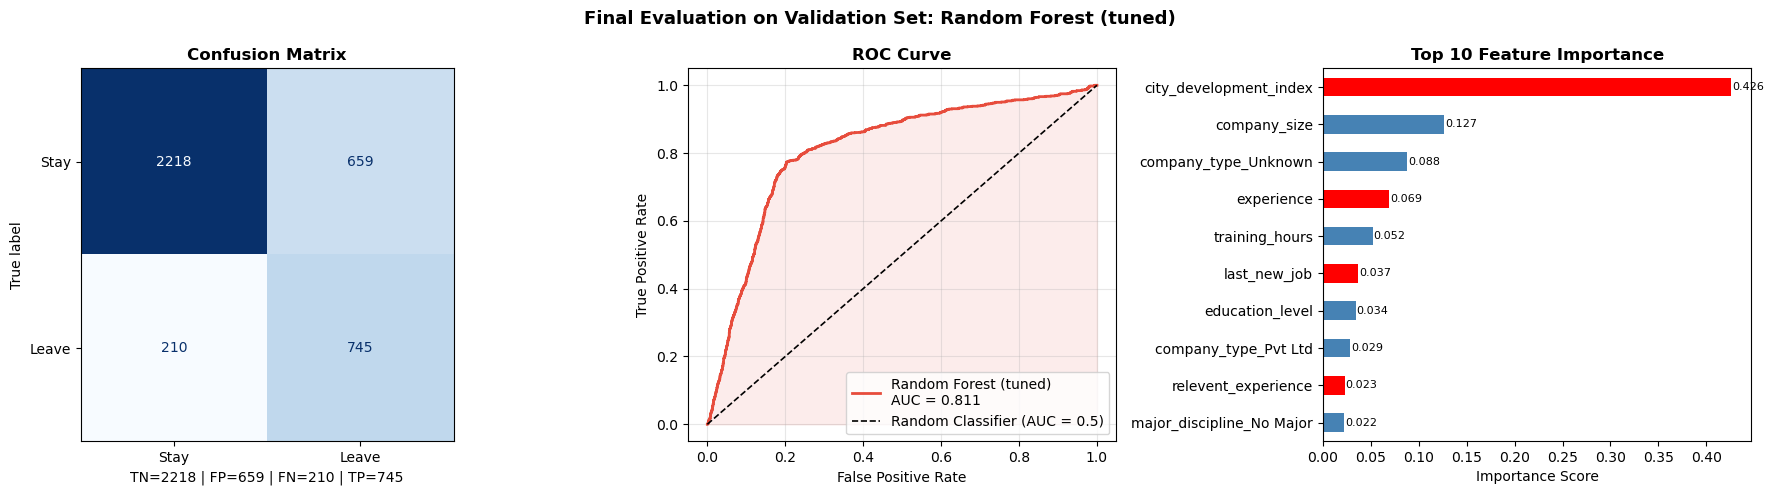

In [39]:
# Predictions from final selected model
y_pred = final_model.predict(X_val)
y_prob = final_model.predict_proba(X_val)[:, 1]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Confusion Matrix ───────────────────────────────
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Stay', 'Leave']
)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontweight='bold')

tn, fp, fn, tp = cm.ravel()
axes[0].set_xlabel(f'TN={tn} | FP={fp} | FN={fn} | TP={tp}')

# ── ROC Curve ──────────────────────────────────────
fpr, tpr, _ = roc_curve(y_val, y_prob)
roc_auc = roc_auc_score(y_val, y_prob)

axes[1].plot(
    fpr, tpr,
    lw=2,
    color='#e74c3c',
    label=f'{best_val_name}\nAUC = {roc_auc:.3f}'
)

axes[1].plot(
    [0, 1], [0, 1],
    'k--',
    lw=1.2,
    label='Random Classifier (AUC = 0.5)'
)

axes[1].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

# ── Feature Importance ─────────────────────────────
highlight_features = [
    'experience',
    'relevent_experience',
    'city_development_index',
    'last_new_job'
]

if hasattr(final_model, 'feature_importances_'):
    feat_imp = pd.Series(
        final_model.feature_importances_,
        index=X_train.columns
    )

    feat_imp = (
        feat_imp.sort_values(ascending=False)
                .head(10)
                .sort_values(ascending=True)
    )

    bar_colors = [
        'red' if f in highlight_features else 'steelblue'
        for f in feat_imp.index
    ]

    feat_imp.plot(
        kind='barh',
        ax=axes[2],
        color=bar_colors
    )

    axes[2].set_title(
        'Top 10 Feature Importance',
        fontweight='bold'
    )
    axes[2].set_xlabel('Importance Score')

    for patch, value in zip(axes[2].patches, feat_imp.values):
        axes[2].text(
            value + 0.001,
            patch.get_y() + patch.get_height()/2,
            f'{value:.3f}',
            va='center',
            fontsize=8
        )
else:
    axes[2].text(
        0.5, 0.5,
        'Feature importance\nnot available',
        ha='center',
        va='center',
        transform=axes[2].transAxes
    )
    axes[2].set_title('Feature Importance', fontweight='bold')

plt.suptitle(
    f'Final Evaluation on Validation Set: {best_val_name}',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

**Interpretation — Confusion Matrix:**

True Positives (745): The model correctly identified 78.0% of leavers.
False Negatives (210): The model missed 22.0% of leavers – this is the most costly error.
False Positives (659): The model sent 659 false alarms – acceptable given the high Recall.


**Interpretation — ROC Curve:**

The ROC curve shows the model’s ability to distinguish between Stay and Leave across all thresholds. The AUC of 0.8109 indicates good discriminative power (AUC > 0.8 is considered excellent).

**Intepretation - Feature Importance**

Among all features, `city_development_index` ranks first with an importance score of 0.426 — more than three times higher than the second-ranked feature (`company_size`, 0.127). `Experience` ranks 4th (0.069), while `last_new_job` (0.037) and `relevent_experience` (0.023) show relatively lower predictive power in this model.


<a id='9-prediction'></a>
## 9. Prediction on Test Set & Conclusion

### 9.1 Predict on Test Set

In [40]:
X_test = test_fe

# Predict probabilities from all 3 models
proba_LR = lr_model.predict_proba(X_test)[:, 1]
proba_RF = rf_best.predict_proba(X_test)[:, 1]
proba_GB = gb_best.predict_proba(X_test)[:, 1]

# Binary predictions (threshold = 0.5)
pred_LR = (proba_LR >= 0.5).astype(int)
pred_RF = (proba_RF >= 0.5).astype(int)
pred_GB = (proba_GB >= 0.5).astype(int)

# Comparison table
results = pd.DataFrame({
    'enrollee_id':    test_ids,
    'leave_proba_LR': proba_LR.round(4),
    'leave_proba_RF': proba_RF.round(4),
    'leave_proba_GB': proba_GB.round(4),
    'predicted_target': pred_RF,
})
results = results.sort_values('leave_proba_RF', ascending=False)

print('=' * 60)
print('LEAVE PROBABILITY STATISTICS (Test Set)')
print('=' * 60)
print(f"{'Model':<25} {'Mean Proba':<15} {'Std Dev'}")
print('-' * 55)
print(f"{'Logistic Regression':<25} {proba_LR.mean():.4f}          {proba_LR.std():.4f}")
print(f"{'Random Forest':<25} {proba_RF.mean():.4f}          {proba_RF.std():.4f}")
print(f"{'Gradient Boosting':<25} {proba_GB.mean():.4f}          {proba_GB.std():.4f}")

print('\n' + '=' * 60)
print('PREDICTED LEAVE RATE ON TEST SET (threshold = 0.5)')
print('=' * 60)
print(f'  Logistic Regression : {pred_LR.mean()*100:.2f}%')
print(f'  Random Forest       : {pred_RF.mean()*100:.2f}%')
print(f'  Gradient Boosting   : {pred_GB.mean()*100:.2f}%')



print('\n' + '=' * 60)
print(f'PREDICTION SUMMARY — Final Model ({best_val_name})')
print('=' * 60)

final_pred = final_model.predict(X_test)
final_proba = final_model.predict_proba(X_test)[:, 1]

print(f'  Predicted Stay  (0): {(final_pred == 0).sum():,}')
print(f'  Predicted Leave (1): {(final_pred == 1).sum():,}')
print(f'  Total candidates   : {len(final_pred):,}')
print('=' * 60)

# Export
results.to_csv('all_models_comparison.csv', index=False)
print('\n Saved: all_models_comparison.csv')

LEAVE PROBABILITY STATISTICS (Test Set)
Model                     Mean Proba      Std Dev
-------------------------------------------------------
Logistic Regression       0.4506          0.2236
Random Forest             0.4161          0.2368
Gradient Boosting         0.2553          0.2134

PREDICTED LEAVE RATE ON TEST SET (threshold = 0.5)
  Logistic Regression : 40.35%
  Random Forest       : 34.66%
  Gradient Boosting   : 24.89%

PREDICTION SUMMARY — Final Model (Random Forest (tuned))
  Predicted Stay  (0): 1,391
  Predicted Leave (1): 738
  Total candidates   : 2,129

 Saved: all_models_comparison.csv


**Intepretation**:

- Leave probability prediction: Random Forest predicts that 34.7% of test candidates (738 out of 2,129) are likely to leave, which is slightly above the training baseline of 25% — consistent with its Recall‑focused optimization.

-  Probability distribution: It also shows the highest probability spread (Std = 0.2368), meaning it separates high‑risk from low‑risk candidates better than the other models. Logistic Regression predicts a higher leave rate (40.4%), while Gradient Boosting is more conservative (24.9%).

With 738 candidates flagged as high-risk, HR can prioritize retention efforts on the top 20-30% (highest leave_proba scores) rather than all 738. Using probability scores (not just binary prediction) allows more efficient resource allocation.

In [41]:
# Submission file (Final model only)
submission = pd.DataFrame({
    'enrollee_id':      test_ids,
    'leave_proba':      final_proba.round(4),
    'predicted_target': final_pred
}).sort_values('leave_proba', ascending=False)

submission.to_csv('submission_final.csv', index=False)

print('Top 10 Highest-Risk Candidates:')
print(submission.head(10).to_string(index=False))
print(f'\n Saved: submission_final.csv')

Top 10 Highest-Risk Candidates:
 enrollee_id  leave_proba  predicted_target
       32795       0.8604               1.0
       18519       0.8579               1.0
        3432       0.8511               1.0
       20035       0.8505               1.0
       12142       0.8497               1.0
         462       0.8482               1.0
       32233       0.8447               1.0
       29629       0.8439               1.0
       25408       0.8429               1.0
        7679       0.8413               1.0

 Saved: submission_final.csv


### 9.2 Conclusion

#### Summary of Findings

| Aspect | Finding |
|---|---|
| **Target imbalance** | 75% Stay / 25% Leave — priority metric is Recall, not Accuracy |
| **Best CV model** | Automatically selected based on highest Recall in cross-validation |
| **Key predictors** | `city_development_index`, `last_new_job`, `experience`, `relevent experience` |
| **Generalization** | Small Overfit Gap → model generalizes well to unseen data |

#### Model Performance Summary

- **Logistic Regression** provides a good, interpretable baseline — suitable when explanations for stakeholders are needed.
- **Random Forest** and **Gradient Boosting** significantly improve Recall — best when the priority is correctly identifying candidates who intend to leave.
- The best model is automatically selected based on CV Recall.

#### Hypothesis summary

| Hypothesis | EDA Evidence | Feature Importance Evidence | Conclusion |
|------------|--------------|----------------------------|------------|
| **H1** (last_new_job as strong indicator) | "Never" group: 30.1%; 1 year: 26.4%; >4 years: 18.2% | Rank #6 (0.037) | **Not supported** — Although EDA shows clear differences in leave rates across groups, `last_new_job` ranks only 6th (0.037), far behind the top predictor. Job mobility history is **not** a strong indicator compared to other features |
| **H2** (experience & relevant experience contribute significantly) | Experience: 45.4% → 15.7%; Relevant exp: 33.8% vs 21.5% | Rank #4 (0.069) & Rank #9 (0.023) | **Partially supported** — Both features show clear EDA trends, but their importance scores are moderate (experience #4) and low (relevent_experience #9), suggesting contribution but not dominance |
| **H3** (city_development_index contributes significantly) | Correlation r = -0.342 (moderate negative) | Rank #1 (0.426) | **Strongly supported** — `city_development_index` is the most important predictor (0.426, >3x higher than #2), confirming regional development conditions play a dominant role in predicting attrition |

---

### 9.3 Recommendations

**For the HR Department:**

1. **Prioritize by probability, not just binary label**: Instead of only checking `predicted_target`, use `leave_proba` to rank candidates by risk level and focus retention efforts on the top 20–30% highest-risk individuals.

2. **Pay attention to the "never changed job" group**: This group may seem stable, but the data shows they have the highest leave rate (~30%) — they are likely fresh graduates seeking their next step.

3. **City Development Index is a strong signal**: Candidates from less developed cities tend to seek larger markets. Relocation support or remote work options may help retain this group.

4. **Focus on low-experience candidates**: Leave rate drops sharply with experience — investing in mentoring and clear career paths for junior candidates will help reduce turnover.

**For the Data Science Team (model improvements):**

- Try **SMOTE** or adjusting the **threshold** (instead of 0.5) to further improve Recall.
- Add feature interactions (e.g., `experience × city_development_index`).
- Try **XGBoost** or **LightGBM** for potentially better results than Gradient Boosting.

### 9.4 Limitations

- Limited features: The dataset does not include important HR-related factors such as salary, job satisfaction, or manager quality.

- Class imbalance handling: Only class_weight='balanced' was used; alternative methods such as SMOTE or threshold tuning were not explored.

- Lack of longitudinal data: The dataset is cross-sectional and does not capture changes in employee behavior over time.

- No real-world validation: The model was evaluated only on historical test data and has not been tested in a live HR environment.

### 9.5 Future Work
- Collect longitudinal data to build models that can predict employee turnover trends over time.
  
- Integrate additional internal data sources, such as employee surveys and performance evaluations, to improve predictive accuracy.

- Develop an interactive dashboard that enables HR teams to visually explore and monitor high-risk employee groups.